# Unemployment Analysis with Python
### Exploring regional and temporal trends in unemployment, with focus on COVID-19 impact in India

**Objective:** Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

In [1]:
import zipfile
with zipfile.ZipFile('/content/archive (1).zip','r') as z:
  z.extractall('/content/')
  print(z.namelist())

['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
%matplotlib inline

## 1. Data Loading & Initial Inspection

In [22]:
print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nNull values per column:\n", df.isnull().sum())

Shape of dataset: (740, 8)

Column names: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area', 'Month']

Data types:
 Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
Month                                              object
dtype: object

Null values per column:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                 

In [23]:
# Strip whitespace from column names (raw headers have leading spaces, e.g. ' Date')
df.columns = df.columns.str.strip()

# Strip whitespace from string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Check and remove duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows found:", dup_count)
df = df.drop_duplicates()

# Convert numeric columns explicitly
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed',
                 'Estimated Labour Participation Rate (%)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Drop rows with any remaining nulls (fully blank rows in the source file)
df = df.dropna().reset_index(drop=True)

print("\nShape after cleaning:", df.shape)
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("\nData types after conversion:\n", df.dtypes)

Duplicate rows found: 0

Shape after cleaning: (740, 8)
Date range: 2019-05-31 to 2020-06-30

Data types after conversion:
 Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
Month                                              object
dtype: object


## 2. Descriptive Statistics

In [24]:
df[numeric_cols].describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


**Observation:** The unemployment rate ranges from close to 0% up to over 70% in extreme cases (a handful of states/months hit crisis-level spikes during the April–May 2020 lockdown), while the typical rate before the pandemic sits in the single digits — this wide spread is what the pre/post-COVID comparison below will quantify.

## 3. Exploratory Data Analysis — Region-wise & Month-wise Trends

In [25]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
region_avg.round(2)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


In [26]:
df['Month'] = df['Date'].dt.month_name()
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean().reindex(month_order).dropna()
monthly_avg.round(2)

,Estimated Unemployment Rate (%)
Month,
January,9.95
February,9.96
March,10.70
April,23.64
May,16.65
June,10.55
July,9.03
August,9.64
September,9.05


***Observation:*** Tripura (28.35%), Haryana (26.28%), and Jharkhand (20.58%) have the highest average unemployment rates across the full period, while Meghalaya (4.80%), Odisha (5.66%), and Assam (6.43%) have the lowest. Month-wise, April sees a dramatic spike to 23.64%, more than double the March figure (10.70%) — this lines up exactly with India's nationwide COVID-19 lockdown, which began March 25, 2020. The rate begins recovering in May (16.65%) and largely normalizes by June (10.55%), suggesting the shock was sharp but partially transient rather than a sustained structural shift within this dataset's window.

## 4. Time-Series Line Chart — Unemployment Rate Over Time (Top 3 States)

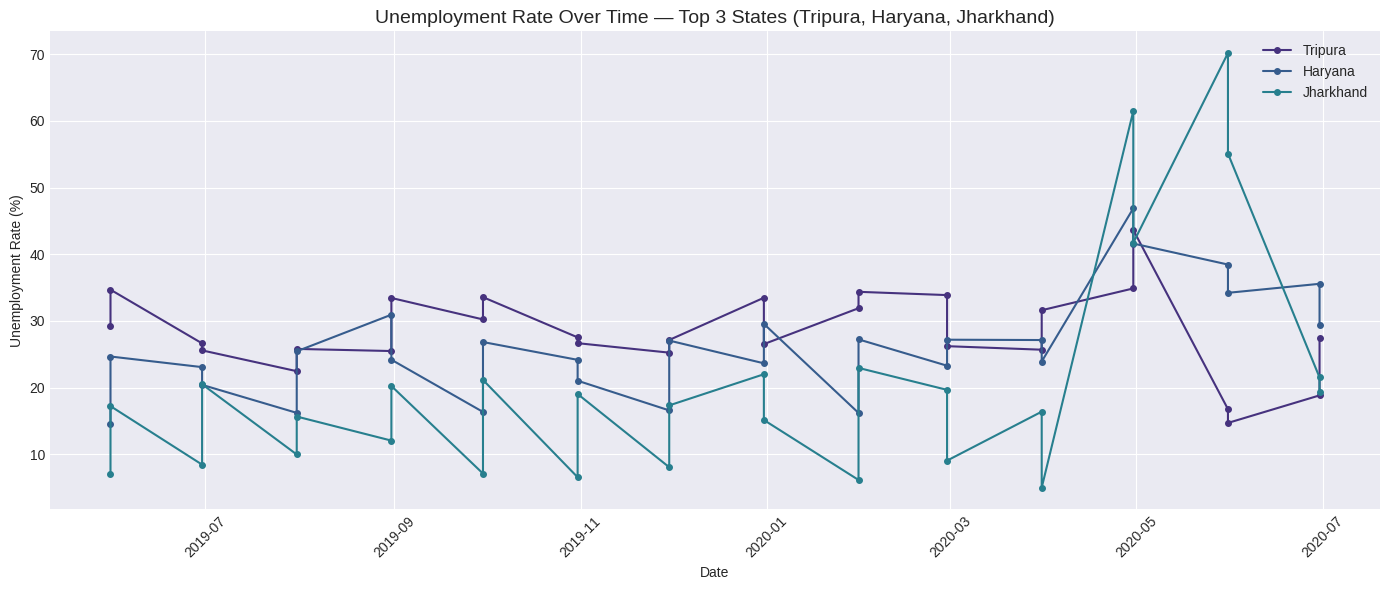

In [37]:
# Get the 3 states with the highest average unemployment rate for comparison
top3_states = region_avg.head(3).index.tolist()

plt.figure(figsize=(14,6))

# Plot each state's unemployment rate over time as a separate line
for state in top3_states:
    # Filter data for this state only and sort chronologically for a clean line
    subset = df[df['Region'] == state].sort_values('Date')
    plt.plot(subset['Date'], subset['Estimated Unemployment Rate (%)'],
              label=state, marker='o', markersize=4)

plt.title('Unemployment Rate Over Time — Top 3 States (Tripura, Haryana, Jharkhand)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()  # show state names to distinguish the lines
plt.xticks(rotation=45)  # rotate dates so they don't overlap
plt.tight_layout()
plt.show()

***Observation:*** Tripura runs at a persistently high baseline unemployment rate throughout the whole period (not just during COVID), which is why it tops the regional ranking even without a pandemic spike — this points to a structural, pre-existing labour market issue rather than a pandemic-driven one. Haryana and Jharkhand, by contrast, show relatively normal rates pre-March 2020 and then spike sharply in April 2020, indicating their high averages are driven primarily by the lockdown shock.

## 5. Bar Chart — Top 10 States by Average Unemployment Rate

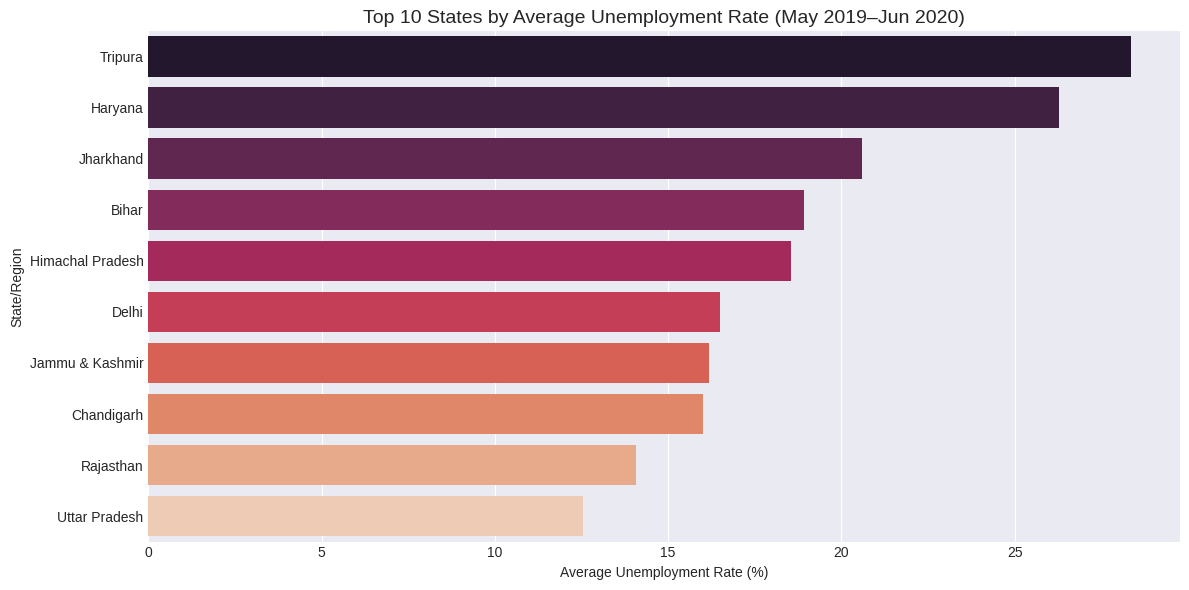

In [33]:
# Take the top 10 states by average unemployment rate for the bar chart
top10 = region_avg.head(10)

plt.figure(figsize=(12,6))

# Horizontal bar chart: state names on y-axis, rate on x-axis (easier to read state labels)
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette='rocket', legend=False)

plt.title('Top 10 States by Average Unemployment Rate (May 2019–Jun 2020)', fontsize=14)
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State/Region')
plt.tight_layout()
plt.show()

***Observation:*** There's a steep drop-off between the top 3 (Tripura, Haryana, Jharkhand — all above 20%) and the rest of the top 10, which cluster between 12–19%. This suggests unemployment stress in this period wasn't evenly distributed but concentrated in a small number of states.

## 6. Heatmap — Correlation Between Unemployment, Employment & Labour Participation Rate

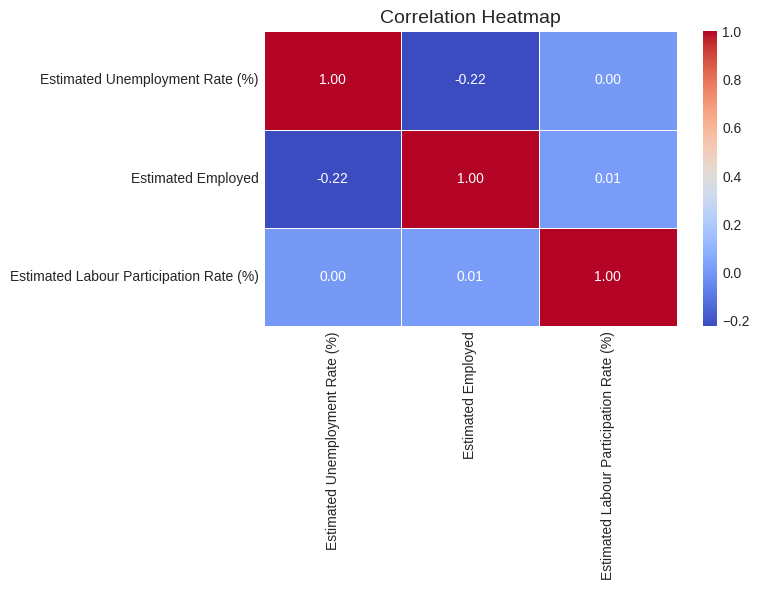

In [34]:

# Compute pairwise correlation between the 3 key numeric indicators
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

# annot=True prints the correlation value inside each cell
# coolwarm colormap: red = positive correlation, blue = negative
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

***Observation:*** Unemployment rate has a weak negative correlation with the number employed (-0.22) and is essentially uncorrelated with labour participation rate (0.003). The near-zero correlation with participation rate is notable — it suggests unemployment spikes in this dataset weren't primarily driven by people entering/leaving the workforce, but rather by existing workers losing jobs while participation stayed roughly constant. This is a classic signature of a sudden external shock (like a lockdown) rather than a slow structural labour market shift.

## 7. Pre-COVID vs. Post-COVID Comparison

In [30]:

covid_start = pd.Timestamp('2020-03-25')  # India's nationwide lockdown start date

pre_covid = df[df['Date'] < covid_start]
post_covid = df[df['Date'] >= covid_start]

pre_mean = pre_covid['Estimated Unemployment Rate (%)'].mean()
post_mean = post_covid['Estimated Unemployment Rate (%)'].mean()
pct_increase = ((post_mean - pre_mean) / pre_mean) * 100

comparison = pd.DataFrame({
    'Period': ['Pre-COVID', 'Post-COVID'],
    'Mean Unemployment Rate (%)': [round(pre_mean, 2), round(post_mean, 2)],
    'Number of Records': [len(pre_covid), len(post_covid)]
})
comparison['% Change'] = ['—', f'+{pct_increase:.1f}%']
comparison

,Period,Mean Unemployment Rate (%),Number of Records,% Change
0,Pre-COVID,9.51,536,—
1,Post-COVID,17.77,204,+86.9%


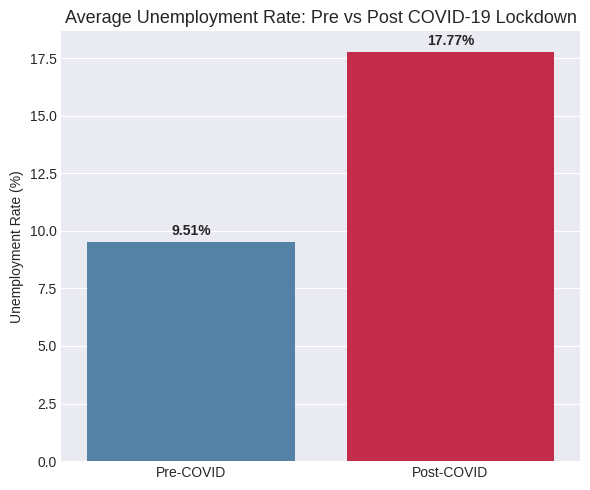

In [35]:
plt.figure(figsize=(6,5))

# Simple 2-bar comparison: pre-COVID mean vs post-COVID mean unemployment rate
sns.barplot(x=['Pre-COVID', 'Post-COVID'], y=[pre_mean, post_mean],
            hue=['Pre-COVID', 'Post-COVID'], palette=['steelblue', 'crimson'], legend=False)

plt.title('Average Unemployment Rate: Pre vs Post COVID-19 Lockdown', fontsize=13)
plt.ylabel('Unemployment Rate (%)')

# Label each bar with its exact value for readability
for i, v in enumerate([pre_mean, post_mean]):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

***Observation:*** The average unemployment rate nearly doubled, rising from 9.51% pre-lockdown to 17.77% post-lockdown — an 86.9% increase. This is a large, statistically obvious shift even at a glance, confirming that India's March 2020 lockdown had an immediate and severe effect on employment across the states in this dataset.

## 8. Conclusion & Key Insights

1. **The COVID-19 lockdown caused an ~87% spike in average unemployment**
   (9.51% → 17.77%), concentrated almost entirely in April 2020 (23.64% monthly
   average), with partial recovery by June 2020 (10.55%) — indicating a sharp
   but short-lived shock within this dataset's window rather than a permanent
   structural collapse.

2. **Unemployment stress was not evenly distributed.** Tripura, Haryana, and
   Jharkhand had average rates 3–4x higher than the lowest states (Meghalaya,
   Odisha, Assam). Tripura's high rate was already elevated before COVID,
   suggesting a pre-existing structural issue, while Haryana and Jharkhand's
   high averages were driven specifically by the lockdown spike.

3. **Unemployment rate was nearly uncorrelated with labour participation rate
   (r ≈ 0.003)**, implying the crisis was driven by job losses among people
   already in the workforce rather than people entering or exiting the labour
   market — consistent with a sudden-shock event like a lockdown rather than
   a gradual economic shift.